### COPOD (Copula-Based Outlier Detection)

COPOD is a highly scalable, non-parametric anomaly detection algorithm that models multivariate data distributions using empirical copulas. The algorithm bypasses the need for expensive parameter estimation by operating directly on the Empirical Cumulative Distribution Functions (ECDFs) of individual features. For a given multi-dimensional data point x=(x1​,x2​,…,xd​), the model evaluates how unusual it is by computing both its left-tail and right-tail probabilities across each feature j∈{1,…,d} relative to the baseline training data:

$Uj​=P(Xj​≤xj​)$ and $Vj​=P(Xj​>xj​)$

To isolate extreme market shocks regardless of their direction, addressing the asymmetry blind spot between explosive market euphoria and sharp panic sell-offs, the framework evaluates the minimum tail probability per dimension:

$Ψj​(xj​)=min(Uj​,Vj​)$

These independent feature tail probabilities are mapped into an aggregate, continuous anomaly score using a negative log-likelihood transformation under an empirical copula independence boundary condition:

$COPOD Score(x)=1/d∑​−ln(Ψj​(xj​))$

A high final score indicates that multiple features are simultaneously experiencing severe tail movements, signaling a structural market regime shift.

## Load and prepare the real BC4 market dataset

This section mirrors the dataset preparation used in `deep_learning_models.ipynb`: it reads the Bloomberg market panel, converts price-like series to log returns, differences rate series, preserves the anomaly labels, and creates normal-only training, cross-validation, and held-out test splits for risk-management evaluation.


Dataset path: Dataset4_EWS.xlsx
Stationary feature matrix: 1110 observations x 42 features
Total anomalies after stationarity/dropna: 237 (21.35%)
Training set: 698 normal observations
Cross-validation set: 205 observations (87 normal, 118 anomalies)
Test set: 207 observations (88 normal, 119 anomalies)
Anomaly base rate on test set: 57.49%


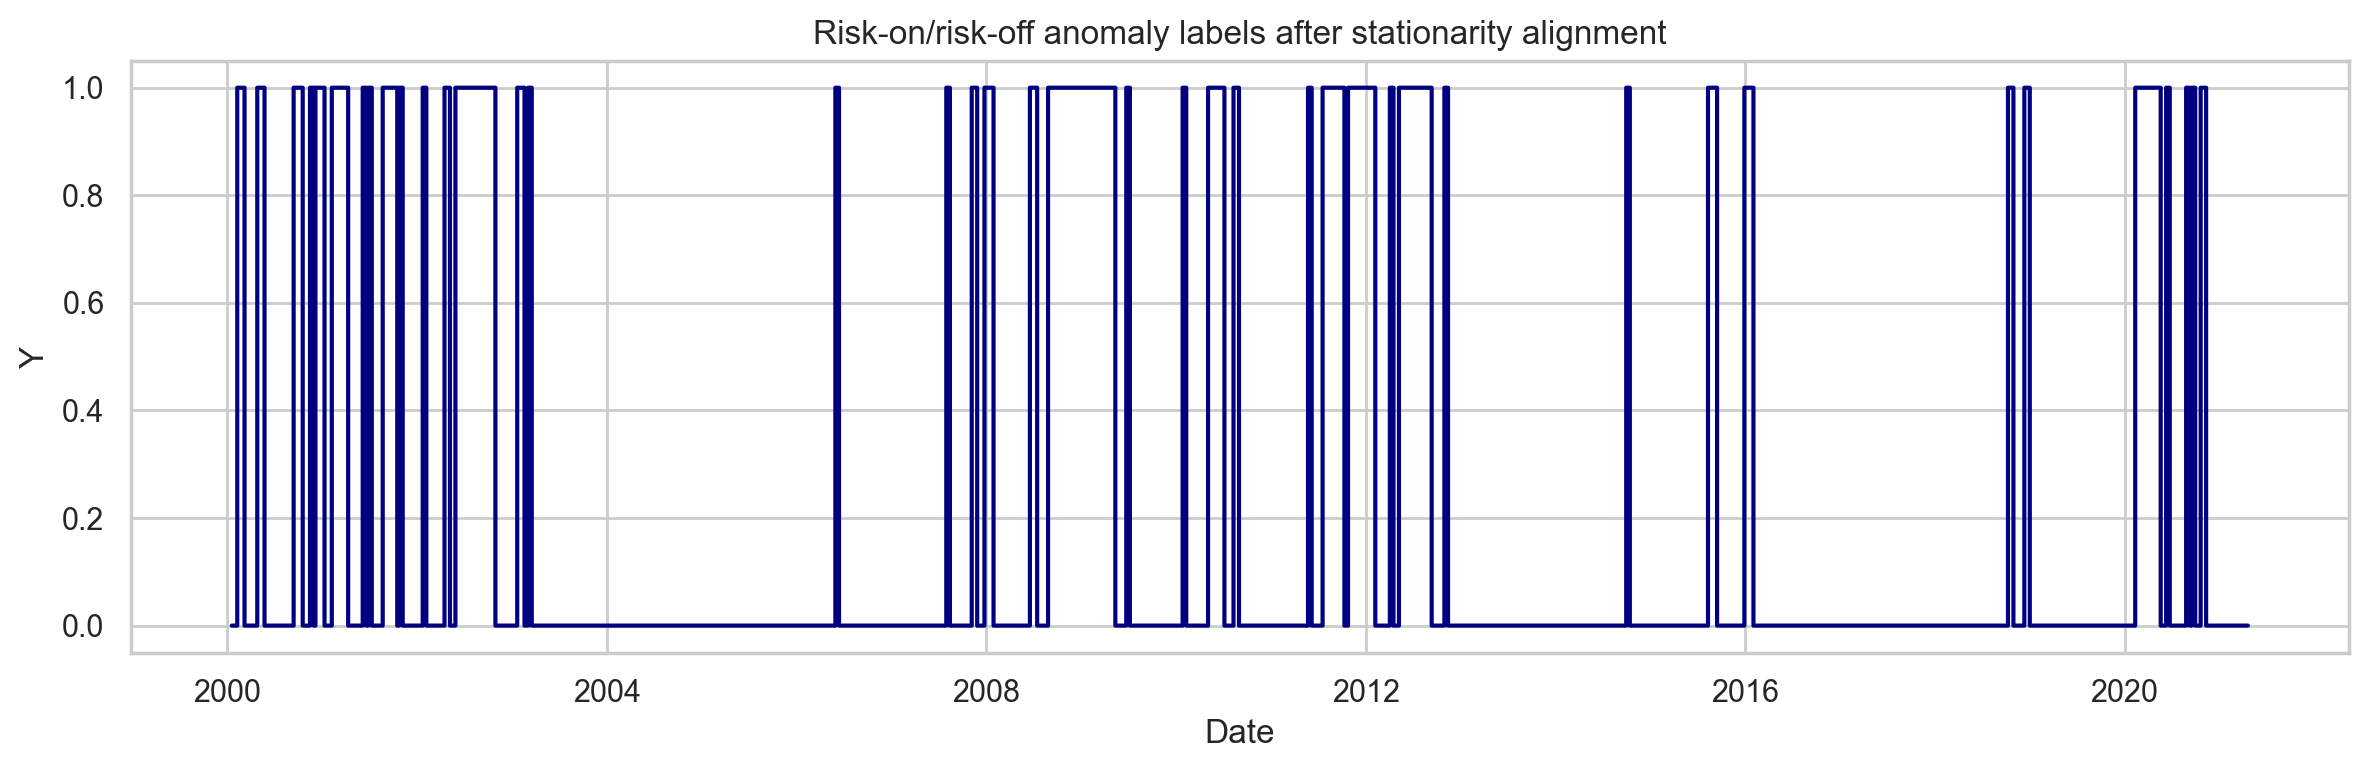

In [2]:
from __future__ import annotations

import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyod.models.copod import COPOD
from sklearn.decomposition import PCA
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

%config InlineBackend.figure_format = 'retina'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]

FIGURE_DIR = Path("BC4/figures") if Path("BC4").is_dir() else Path("figures")
FIGURE_FORMATS = ("png", "pdf")


def safe_filename(name: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", str(name).lower()).strip("_")
    return slug or "figure"


def export_figure(fig, filename: str, dpi: int = 300):
    """Save a matplotlib figure as PNG and PDF with a stable notebook-local name."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    stem = safe_filename(filename)
    exported_paths = []
    for extension in FIGURE_FORMATS:
        output_path = FIGURE_DIR / f"{stem}.{extension}"
        save_kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            save_kwargs["dpi"] = dpi
        fig.savefig(output_path, **save_kwargs)
        exported_paths.append(output_path)
    return exported_paths


dataset_path = Path("Dataset4_EWS.xlsx")
if not dataset_path.exists() and Path("BC4/Dataset4_EWS.xlsx").exists():
    dataset_path = Path("BC4/Dataset4_EWS.xlsx")

data_df = pd.read_excel(dataset_path, sheet_name="Markets")
metadata_df = pd.read_excel(dataset_path, sheet_name="Metadata")

date_col = "Date" if "Date" in data_df.columns else data_df.columns[0]
y_col = "Y" if "Y" in data_df.columns else None
if y_col is None:
    raise ValueError("Expected an anomaly label column named 'Y' in the Markets sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col).sort_index()

X_df = data_df.drop(columns=[y_col])
y_raw = data_df[y_col].astype(int).values

indices_currencies = [col for col in X_df.columns if col in [
    "XAUBGNL", "BDIY", "CRY", "Cl1", "DXY", "EMUSTRUU", "GBP", "JPY", "LF94TRUU",
    "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU",
    "MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "VIX"
]]

interest_rates = [col for col in X_df.columns if col in [
    "EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
    "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
    "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in indices_currencies:
    stationary_df[col] = np.diff(np.log(X_df[col].astype(float)))

for col in interest_rates:
    stationary_df[col] = np.diff(X_df[col].astype(float))

if "ECSURPUS" in X_df.columns:
    stationary_df["ECSURPUS"] = X_df["ECSURPUS"].astype(float).values[1:]

y_stationary = y_raw[1:]
stationary_df = stationary_df.replace([np.inf, -np.inf], np.nan)
valid_mask = stationary_df.notna().all(axis=1)
stationary_df = stationary_df.loc[valid_mask]
y_stationary = y_stationary[valid_mask.to_numpy()].astype(int)
feature_names = stationary_df.columns.to_list()

X = stationary_df.values
y = y_stationary
dates = stationary_df.index.to_numpy()

X_shuffled, y_shuffled, dates_shuffled = shuffle(X, y, dates, random_state=SEED)
normal_mask = y_shuffled == 0
anomaly_mask = y_shuffled == 1
X_normal, dates_normal = X_shuffled[normal_mask], dates_shuffled[normal_mask]
X_anomaly, dates_anomaly = X_shuffled[anomaly_mask], dates_shuffled[anomaly_mask]

n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]
if n_normal == 0 or n_anomaly < 2:
    raise ValueError("Need normal observations and at least two anomalies for the train/CV/test split.")

train_size = int(0.8 * n_normal)
cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = max(1, int(0.5 * n_anomaly))

X_train_raw = X_normal[:train_size]
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val_raw = np.vstack([X_cv_normal, X_cv_anomaly])
y_cross_val = np.hstack([np.zeros(len(X_cv_normal)), np.ones(len(X_cv_anomaly))]).astype(int)
cv_dates_normal = dates_normal[train_size:train_size + cv_normal_size]
cv_dates_anomaly = dates_anomaly[:cv_anomaly_size]
cv_dates = np.concatenate([cv_dates_normal, cv_dates_anomaly])

X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test_raw = np.vstack([X_test_normal, X_test_anomaly])
y_test = np.hstack([np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))]).astype(int)

test_dates_normal = dates_normal[train_size + cv_normal_size:]
test_dates_anomaly = dates_anomaly[cv_anomaly_size:]
test_dates = np.concatenate([test_dates_normal, test_dates_anomaly])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_cross_val = scaler.transform(X_cross_val_raw)
X_test = scaler.transform(X_test_raw)

# Backward-compatible aliases for the grouped COPOD blocks below.
X_train_scaled = X_train
X_cv_scaled = X_cross_val
X_test_scaled = X_test

print(f"Dataset path: {dataset_path}")
print(f"Stationary feature matrix: {stationary_df.shape[0]} observations x {stationary_df.shape[1]} features")
print(f"Total anomalies after stationarity/dropna: {int(y.sum())} ({y.mean() * 100:.2f}%)")
print(f"Training set: {X_train.shape[0]} normal observations")
print(f"Cross-validation set: {X_cross_val.shape[0]} observations ({len(X_cv_normal)} normal, {len(X_cv_anomaly)} anomalies)")
print(f"Test set: {X_test.shape[0]} observations ({len(X_test_normal)} normal, {len(X_test_anomaly)} anomalies)")
print(f"Anomaly base rate on test set: {y_test.mean() * 100:.2f}%")

fig = plt.figure(figsize=(12, 4))
plt.plot(stationary_df.index, y_stationary, drawstyle="steps-post", color="navy")
plt.title("Risk-on/risk-off anomaly labels after stationarity alignment")
plt.xlabel("Date")
plt.ylabel("Y")
plt.tight_layout()
export_figure(fig, "copod_01_stationary_anomaly_labels")
plt.show()


def evaluate_model(y_true, y_pred, anomaly_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2.0, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, anomaly_score)
    roc_auc = auc(fpr, tpr)
    pr_precision, pr_recall, _ = precision_recall_curve(y_true, anomaly_score)
    pr_auc = average_precision_score(y_true, anomaly_score)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    baseline_rate = float(np.mean(y_true))

    print(f"\n{model_name}")
    print(f"Recall:       {recall:.4f}   <- crises caught")
    print(f"FNR:          {fnr:.4f}   <- crises missed (lower is better)")
    print(f"F2:           {f2:.4f}")
    print(f"PR-AUC:       {pr_auc:.4f}  (baseline = {baseline_rate:.4f})")
    print(f"Precision:    {precision:.4f}")
    print(f"F1:           {f1:.4f}")
    print(f"ROC-AUC:      {roc_auc:.4f}")

    fig_cm = plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    export_figure(fig_cm, f"copod_02_confusion_matrix_{model_name}")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC - {model_name}")
    axes[0].legend()

    axes[1].plot(pr_recall, pr_precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline = {baseline_rate:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall - {model_name}")
    axes[1].legend()
    plt.tight_layout()
    export_figure(fig, f"copod_03_roc_pr_{model_name}")
    plt.show()

    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "fnr": fnr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }


def visualize_pca(X_eval, y_true, y_pred, title):
    pca = PCA(n_components=2, random_state=SEED)
    pca.fit(X_train)
    X_eval_pca = pca.transform(X_eval)

    fig, ax = plt.subplots(figsize=(8, 6))
    groups = [
        ((y_true == 0) & (y_pred == 0), "gray", 20, 0.5, "True Negative"),
        ((y_true == 1) & (y_pred == 1), "black", 35, 0.8, "True Positive"),
        ((y_true == 0) & (y_pred == 1), "orange", 45, 0.8, "False Positive"),
        ((y_true == 1) & (y_pred == 0), "magenta", 55, 0.8, "False Negative"),
    ]
    for mask, color, size, alpha, label in groups:
        ax.scatter(X_eval_pca[mask, 0], X_eval_pca[mask, 1],
                   c=color, s=size, alpha=alpha, label=label)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
    ax.legend(loc="best")
    plt.tight_layout()
    export_figure(fig, f"copod_04_pca_{title}")
    plt.show()


The next block restructures 42 raw Bloomberg variables into 4 homogeneous asset families to eliminate feature dilution, which is a failure mode where an isolated shock (e.g., a credit freeze) gets statistically masked by normal noise in other sectors. Sub-models isolate independent tail anomalies within their specific economic domains, which are then stacked into a meta-feature matrix for a master COPOD engine to capture cross-asset risk propagation.

To calibrate the system for live trading, the decision boundary is optimized via a cross-validation sweep using the F2.0​ score:

$F2.0 ​= 5×Precision×Recall /  ((4×Precision)+Recall​)$

By placing twice as much weight on Recall than Precision, the framework explicitly prioritizes establishing a bulletproof safety net to capture systemic crises over the operational inconvenience of false alarms. This provides a highly sensitive, baseline continuous threshold engineered specifically for fund capital preservation.

Optimal CV Threshold: 2.9287
Best CV F-2.0 Score: 0.8654

COPOD (Asset Grouped F-2.0)
Recall:       1.0000   <- crises caught
FNR:          0.0000   <- crises missed (lower is better)
F2:           0.8712
PR-AUC:       0.7299  (baseline = 0.5749)
Precision:    0.5749
F1:           0.7301
ROC-AUC:      0.6386


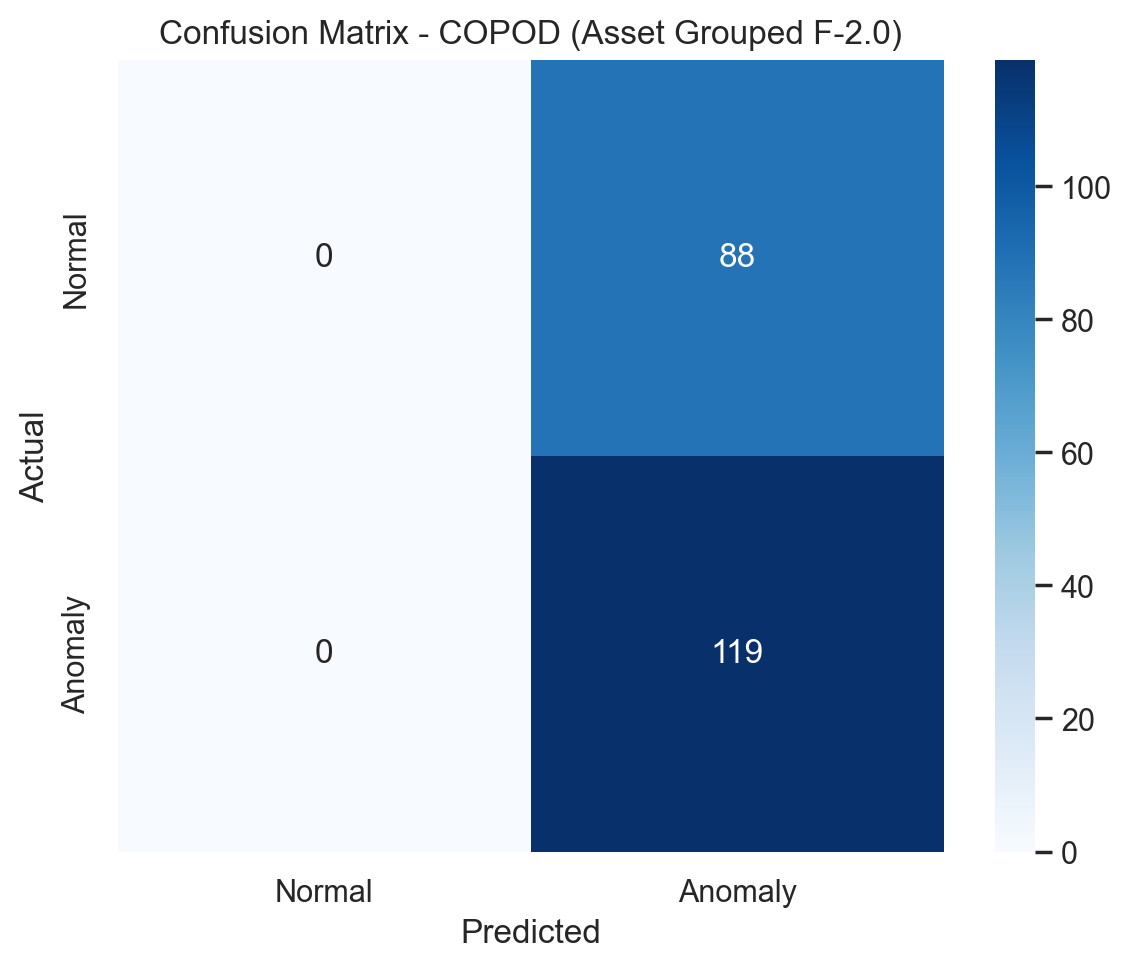

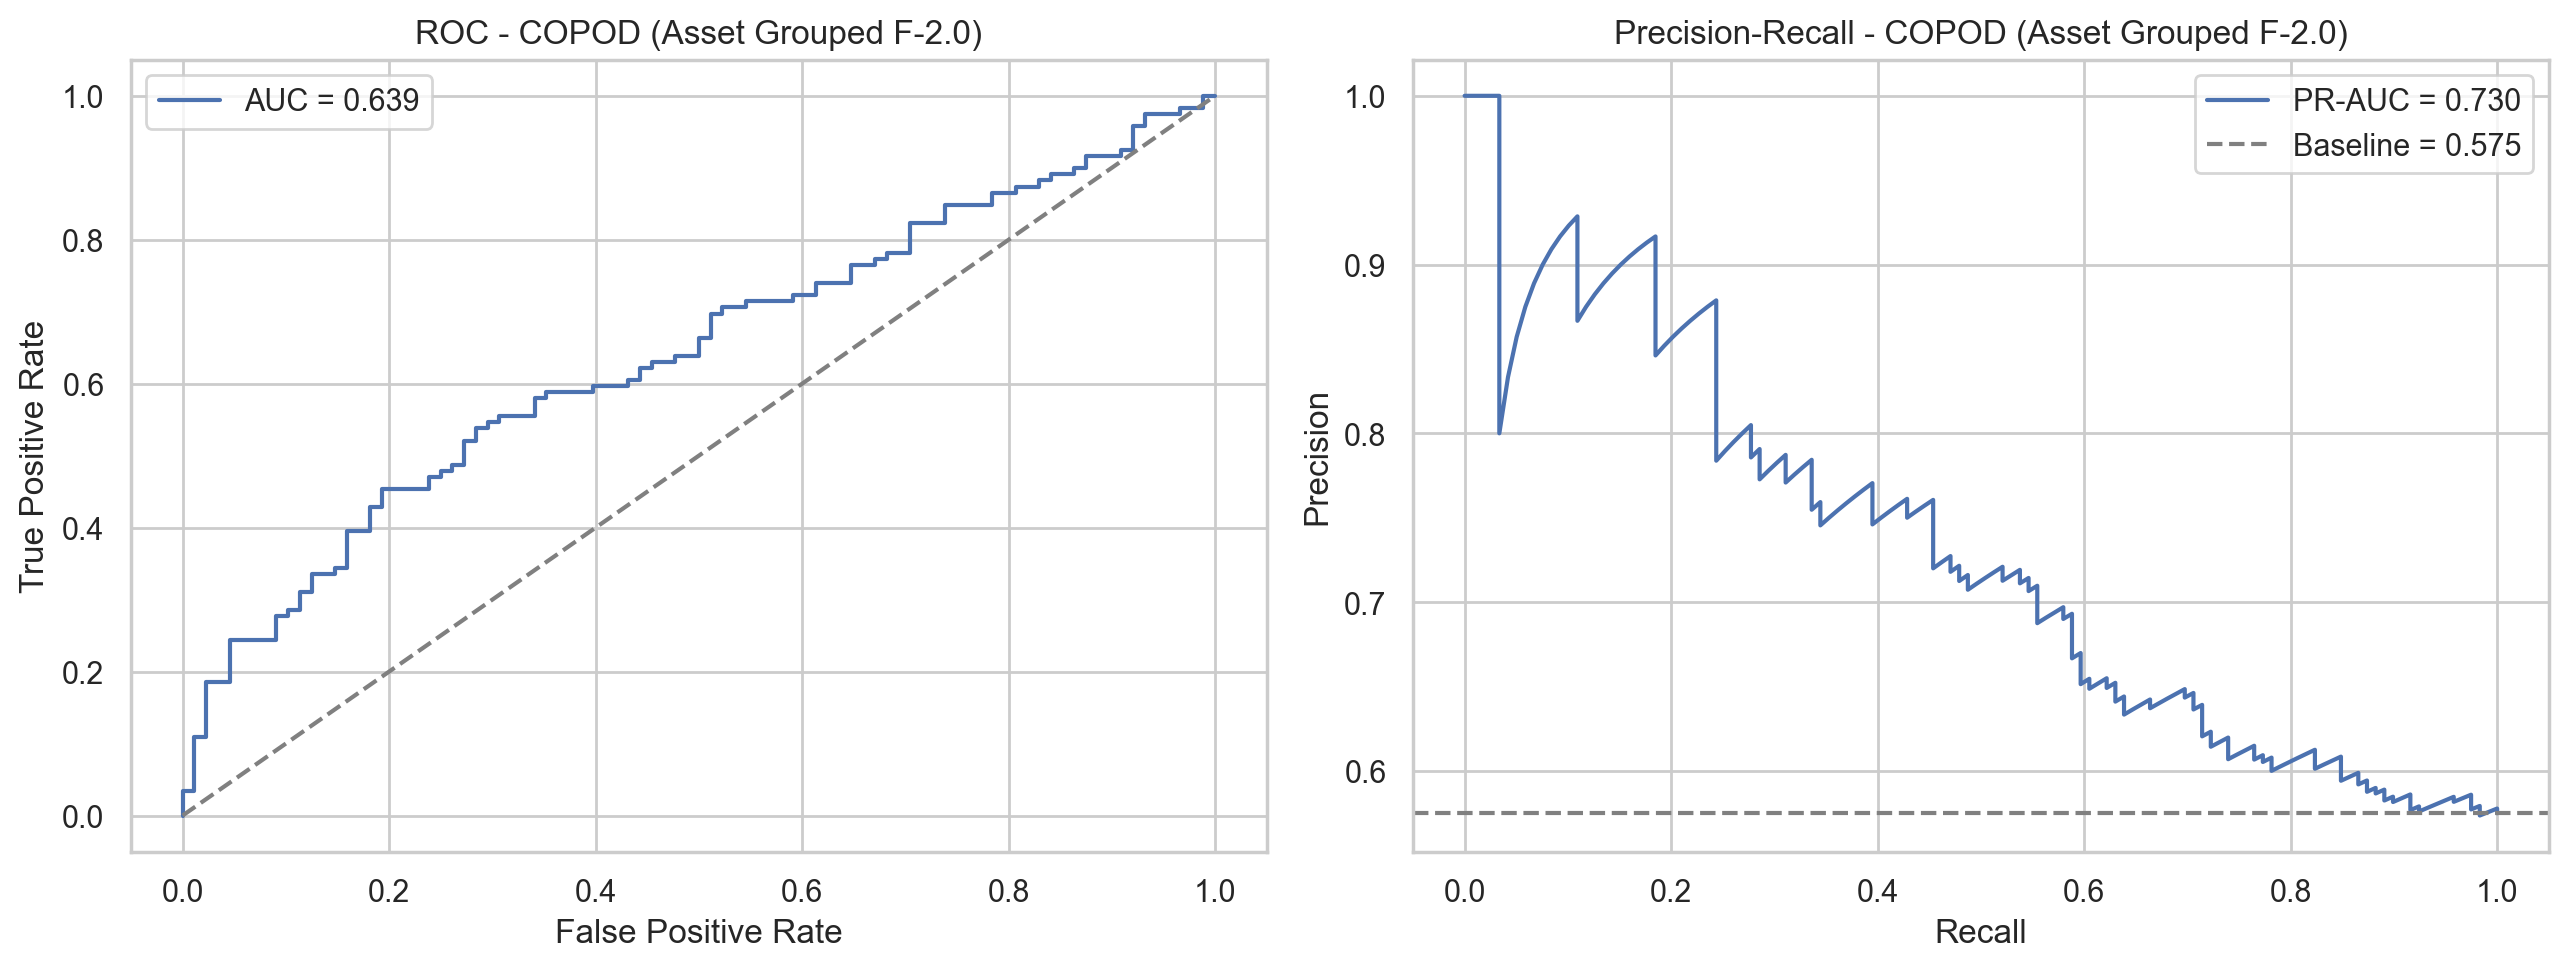

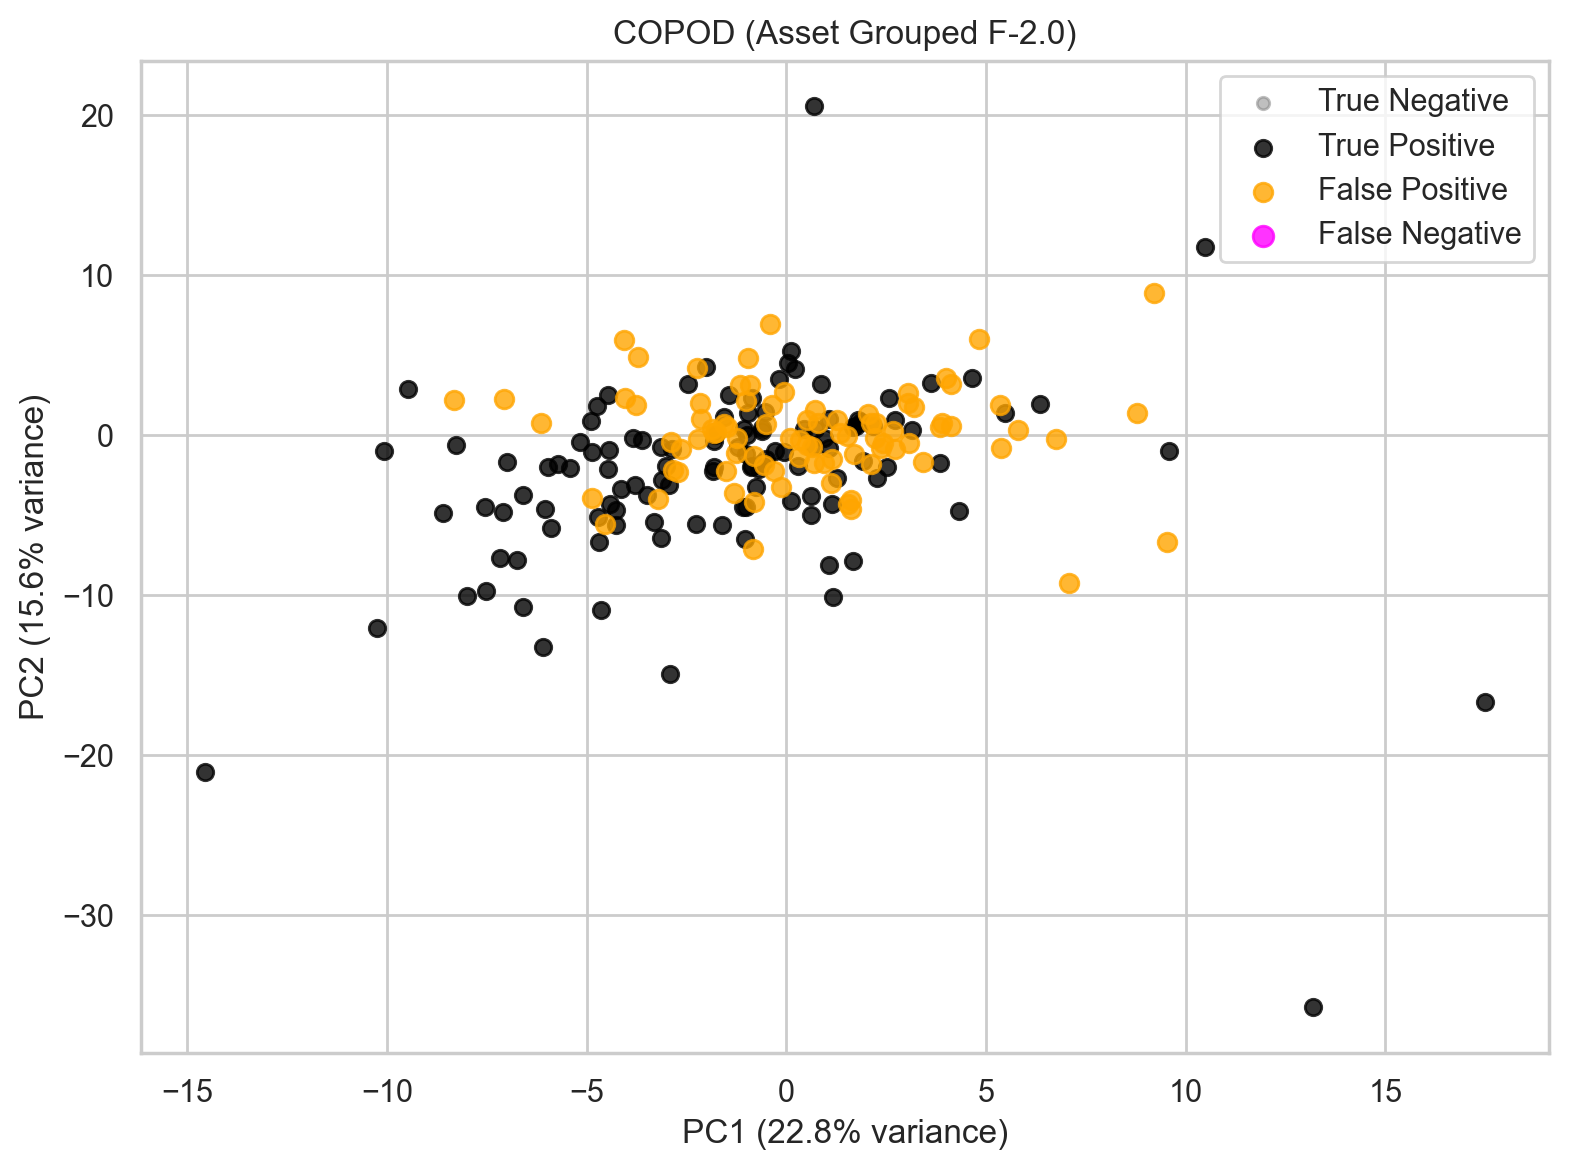

,model,precision,recall,f1,f2,fnr,roc_auc,pr_auc
0,COPOD (Asset Grouped F-2.0),0.574879,1.0,0.730061,0.871157,0.0,0.63856,0.729872


In [3]:
# BETA = 2 means we care twice as much about catching crises (Recall) than false alarms.
BETA_PARAM = 2.0

# Financial families used by the hierarchical COPOD stack.
groups = {
    "Macro_Volatility": ["VIX", "DXY", "ECSURPUS", "EONIA", "US0001M", "USGG3M", "GBP", "JPY"],
    "Fixed_Income": ["GT10", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y",
                     "GTGBP30Y", "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR",
                     "GTJPY2YR", "GTJPY30YR", "USGG2YR", "USGG30YR"],
    "Credit_Markets": ["EMUSTRUU", "LF94TRUU", "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU",
                       "LUACTRUU", "LUMSTRUU"],
    "Equities_Comm": ["MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "BDIY", "CRY", "Cl1", "XAUBGNL"],
}

available_groups = {
    name: [col for col in cols if col in feature_names]
    for name, cols in groups.items()
}
missing_group_features = {
    name: sorted(set(cols) - set(available_cols))
    for name, cols in groups.items()
    for available_cols in [available_groups[name]]
    if set(cols) - set(available_cols)
}
if missing_group_features:
    print("Missing grouped features skipped:")
    for name, missing_cols in missing_group_features.items():
        print(f" - {name}: {missing_cols}")

group_indices = {
    name: [feature_names.index(col) for col in cols]
    for name, cols in available_groups.items()
    if cols
}
if not group_indices:
    raise ValueError("No COPOD feature groups overlap with the prepared dataset columns.")

X_train_sub_train = []
X_train_sub_cv = []
X_train_sub_test = []
sub_models = {}

for name, indices in group_indices.items():
    sub_model = COPOD(contamination=0.1)
    sub_model.fit(X_train_scaled[:, indices])
    sub_models[name] = sub_model

    X_train_sub_train.append(sub_model.decision_function(X_train_scaled[:, indices]))
    X_train_sub_cv.append(sub_model.decision_function(X_cv_scaled[:, indices]))
    X_train_sub_test.append(sub_model.decision_function(X_test_scaled[:, indices]))

X_train_meta = np.column_stack(X_train_sub_train)
X_cv_meta = np.column_stack(X_train_sub_cv)
X_test_meta = np.column_stack(X_train_sub_test)

copod_model = COPOD(contamination=0.1)
copod_model.fit(X_train_meta)

cv_scores = copod_model.decision_function(X_cv_meta)

best_fbeta = -1
optimal_threshold = None
threshold_candidates = np.linspace(cv_scores.min(), cv_scores.max(), 200)

for candidate in threshold_candidates:
    cv_preds_candidate = (cv_scores > candidate).astype(int)
    current_fbeta = fbeta_score(y_cross_val, cv_preds_candidate, beta=BETA_PARAM, zero_division=0)

    if current_fbeta > best_fbeta:
        best_fbeta = current_fbeta
        optimal_threshold = candidate

print(f"Optimal CV Threshold: {optimal_threshold:.4f}")
print(f"Best CV F-{BETA_PARAM} Score: {best_fbeta:.4f}")

copod_score = copod_model.decision_function(X_test_meta)
copod_pred = (copod_score > optimal_threshold).astype(int)

copod_metrics = evaluate_model(y_test, copod_pred, copod_score, f"COPOD (Asset Grouped F-{BETA_PARAM})")
visualize_pca(X_test_scaled, y_test, copod_pred, f"COPOD (Asset Grouped F-{BETA_PARAM})")
pd.DataFrame([copod_metrics])


The following block establishes an operational traffic-light routing architecture designed to filter out the high volume of false alarms generated by the raw F2.0 optimization step. By utilizing a dual-threshold setup calibrated on the validation set, continuous outlier scores are converted into actionable, discrete risk commands:

* RED ALERT: Triggered by an aggressive statistical threshold corresponding to the 85th percentile of validation scores, capturing severe systemic shocks that justify immediate, high-cost portfolio hedging.

* AMBER WARNING: Defined by the baseline F2.0 threshold, acting as an operational buffer zone to capture lower-intensity abnormalities.

* GREEN REGIME: Normal market operations where scores fall below the warning criteria.

The accountability matrix below reports the realized distribution of these routes, the number of crises caught in each warning zone, and how many lower-severity false alarms are kept in the zero-cost monitoring bucket rather than escalated directly to portfolio hedging.


In [4]:
cv_scores = copod_model.decision_function(X_cv_meta)
test_scores = copod_model.decision_function(X_test_meta)

amber_statistical_threshold = optimal_threshold
red_statistical_threshold = np.percentile(cv_scores, 85)

print("Operational Calibration Gates Complete:")
print(f" -> Amber Warning Gate (F-2.0 Optimized) : {amber_statistical_threshold:.4f}")
print(f" -> Red Alert Gate (85th Percentile)     : {red_statistical_threshold:.4f}")

final_routing = []

for score in test_scores:
    if score > red_statistical_threshold:
        final_routing.append("RED ALERT (Deploy Portfolio Hedges)")
    elif score > amber_statistical_threshold:
        final_routing.append("AMBER WARNING (Monitor Positions)")
    else:
        final_routing.append("GREEN (Normal Regime)")

operations_df = pd.DataFrame({
    "Date": pd.to_datetime(test_dates),
    "Actual_Crisis_Label": y_test,
    "COPOD_Score": test_scores,
    "Operational_Routing": final_routing,
})

print("\n" + "-" * 40)
print("RISK OPERATIONS ACCOUNTABILITY MATRIX")
print("-" * 40)
print(operations_df["Operational_Routing"].value_counts())

true_crises_red = operations_df[(operations_df["Actual_Crisis_Label"] == 1) &
                                 (operations_df["Operational_Routing"] == "RED ALERT (Deploy Portfolio Hedges)")].shape[0]

true_crises_amber = operations_df[(operations_df["Actual_Crisis_Label"] == 1) &
                                   (operations_df["Operational_Routing"] == "AMBER WARNING (Monitor Positions)")].shape[0]

true_crises_missed = operations_df[(operations_df["Actual_Crisis_Label"] == 1) &
                                    (operations_df["Operational_Routing"] == "GREEN (Normal Regime)")].shape[0]

false_alarms_defused = operations_df[(operations_df["Actual_Crisis_Label"] == 0) &
                                     (operations_df["Operational_Routing"] == "AMBER WARNING (Monitor Positions)")].shape[0]

total_f2_false_alarms = np.sum((test_scores > optimal_threshold) & (y_test == 0))

print(f"True Crises in RED ALERT Zone:     {true_crises_red}")
print(f"True Crises in AMBER WARNING Zone: {true_crises_amber}")
print(f"True Crises Completely Missed:     {true_crises_missed}")
print(f"False Alarms Successfully Defused: {false_alarms_defused} / {total_f2_false_alarms}")
# Total Caught Crises = RED ALERT + AMBER WARNING


Operational Calibration Gates Complete:
 -> Amber Warning Gate (F-2.0 Optimized) : 2.9287
 -> Red Alert Gate (85th Percentile)     : 8.1293

----------------------------------------
RISK OPERATIONS ACCOUNTABILITY MATRIX
----------------------------------------
Operational_Routing
AMBER WARNING (Monitor Positions)      170
RED ALERT (Deploy Portfolio Hedges)     37
Name: count, dtype: int64
True Crises in RED ALERT Zone:     29
True Crises in AMBER WARNING Zone: 90
True Crises Completely Missed:     0
False Alarms Successfully Defused: 80 / 88


## Risk-managed equity curve

This applies the same full-chronology MXUS backtest pattern used in `deep_learning_models.ipynb`: the benchmark stays invested, while the COPOD-managed curves rotate to cash when the warning or red-alert threshold fires. The shaded region marks the held-out test rows used for the out-of-sample drawdown comparison.


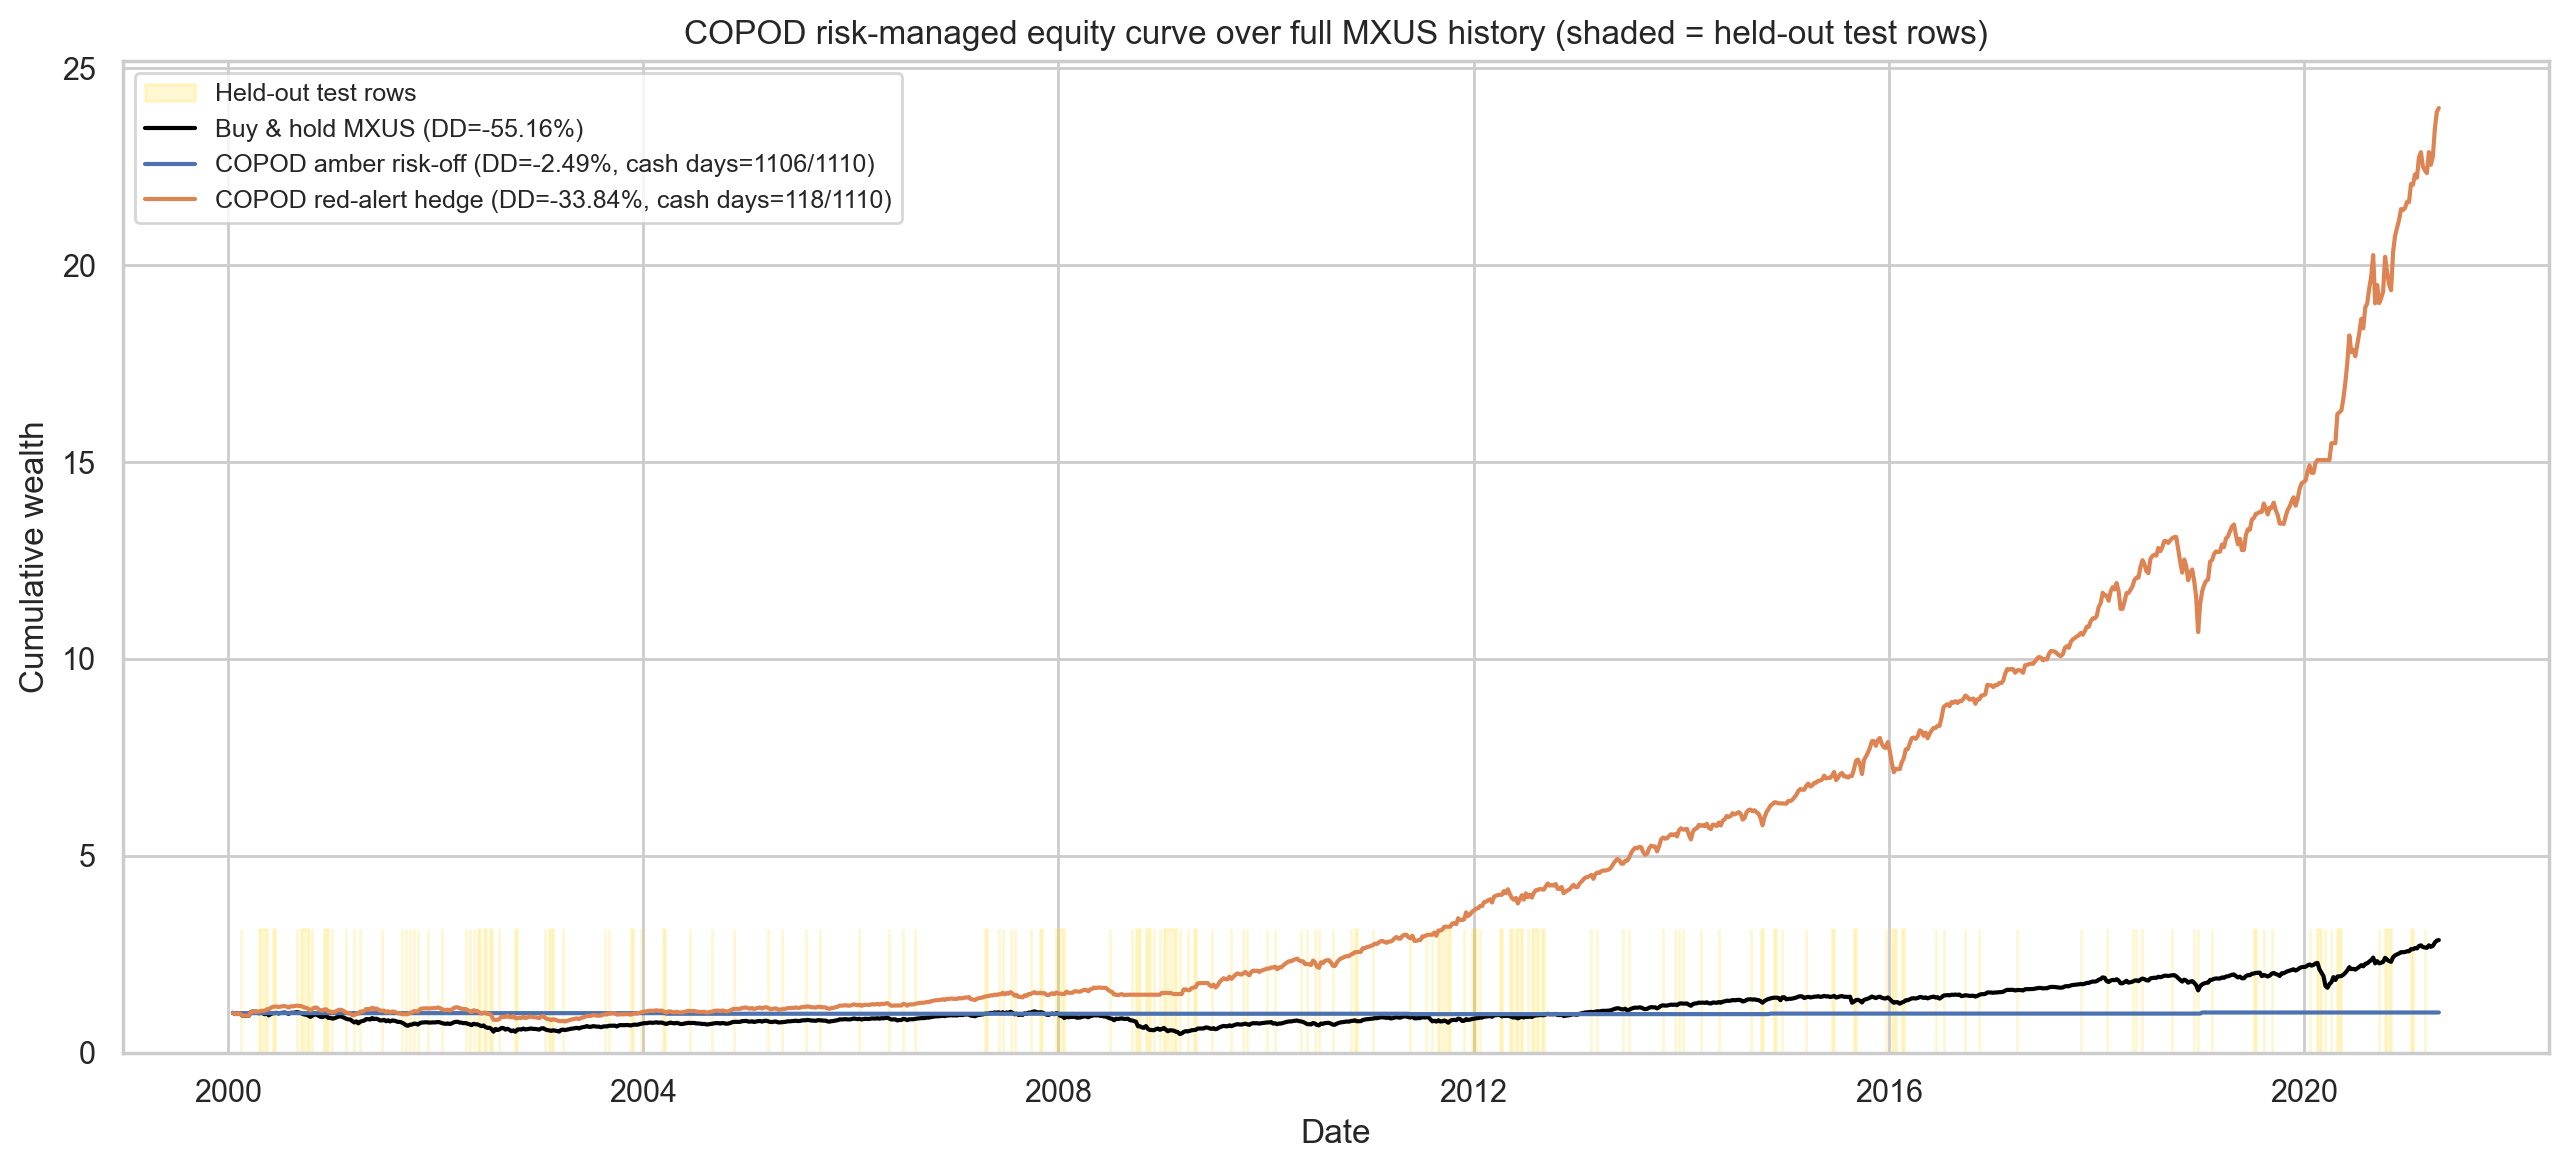


Drawdown comparison. The out-of-sample number is max_drawdown_test_window.


,model,final_wealth,max_drawdown,max_drawdown_test_window,days_in_cash_total,days_in_cash_test,threshold,status
0,Buy & hold MXUS,2.855471,-0.551634,-0.546660,0,0,NaN,passive baseline
1,COPOD amber risk-off,1.016211,-0.024932,-0.024932,1106,206,2.928688,active
2,COPOD red-alert hedge,23.992990,-0.338371,-0.325291,118,44,8.129280,active


In [5]:
def max_drawdown(wealth):
    wealth = np.asarray(wealth)
    if wealth.size == 0:
        return 0.0
    running_max = np.maximum.accumulate(wealth)
    return float(((wealth - running_max) / running_max).min())


if "MXUS" in stationary_df.columns:
    X_all_scaled = scaler.transform(stationary_df.values)
    all_dates = stationary_df.index
    bench_full = stationary_df["MXUS"].to_numpy()
    buyhold_wealth = np.exp(np.cumsum(bench_full))

    # Robust test-row mask via DatetimeIndex.isin (works regardless of internal dtype).
    test_idx = pd.DatetimeIndex(test_dates)
    test_mask_full = all_dates.isin(test_idx)
    assert test_mask_full.sum() == len(test_idx), (
        f"Test-row mask alignment failed: {test_mask_full.sum()} matched vs {len(test_idx)} expected."
    )

    X_all_meta = np.column_stack([
        sub_models[name].decision_function(X_all_scaled[:, group_indices[name]])
        for name in group_indices
    ])
    copod_score_full = copod_model.decision_function(X_all_meta)

    managed_specs = [
        ("COPOD amber risk-off", amber_statistical_threshold),
        ("COPOD red-alert hedge", red_statistical_threshold),
    ]

    fig = plt.figure(figsize=(13, 6))
    ymax = max(buyhold_wealth.max() * 1.1, 1.5)
    plt.fill_between(all_dates, 0, ymax, where=test_mask_full,
                     color="gold", alpha=0.18, step="post", label="Held-out test rows")
    plt.plot(all_dates, buyhold_wealth, color="black", linewidth=1.5,
             label=f"Buy & hold MXUS (DD={max_drawdown(buyhold_wealth):.2%})")

    backtests = [{
        "model": "Buy & hold MXUS",
        "final_wealth": float(buyhold_wealth[-1]),
        "max_drawdown": max_drawdown(buyhold_wealth),
        "max_drawdown_test_window": max_drawdown(buyhold_wealth[test_mask_full]),
        "days_in_cash_total": 0,
        "days_in_cash_test": 0,
        "threshold": np.nan,
        "status": "passive baseline",
    }]

    for label, threshold in managed_specs:
        y_pred_full = (copod_score_full > threshold).astype(int)
        managed_ret = np.where(y_pred_full == 1, 0.0, bench_full)
        managed_wealth = np.exp(np.cumsum(managed_ret))
        plt.plot(all_dates, managed_wealth,
                 label=f"{label} (DD={max_drawdown(managed_wealth):.2%}, "
                       f"cash days={int(y_pred_full.sum())}/{len(y_pred_full)})")
        backtests.append({
            "model": label,
            "final_wealth": float(managed_wealth[-1]),
            "max_drawdown": max_drawdown(managed_wealth),
            "max_drawdown_test_window": max_drawdown(managed_wealth[test_mask_full]),
            "days_in_cash_total": int(y_pred_full.sum()),
            "days_in_cash_test": int(y_pred_full[test_mask_full].sum()),
            "threshold": float(threshold),
            "status": "active",
        })

    plt.title("COPOD risk-managed equity curve over full MXUS history "
              "(shaded = held-out test rows)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative wealth")
    plt.ylim(bottom=0)
    plt.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    export_figure(fig, "copod_05_risk_managed_equity_curve")
    plt.show()

    backtest_df = pd.DataFrame(backtests)
    print("\nDrawdown comparison. The out-of-sample number is max_drawdown_test_window.")
    display(backtest_df)
else:
    print("MXUS not available -- skipping risk-managed equity-curve backtest.")
